                                                   PROYECTO FINAL
                                       APRENDIZAJE SUPERVISADO (CLASIFICACIÓN).
             BY: LOLA REINA

  ¡COMENCEMOS!

1. IMPORTACIÓN DE LIBRERIAS, HERRAMIENTAS DE scikit-learn NECESARIAS E IMPORTANCIÓN  DE LOS MODELOS ELEGIDOS.
2. CREACIÓN DEL DATA SET.
3. EXPLORACIÓN DE DATOS (EDA)
4. PREPROCESAMIENTO DE DATOS
5. ENTRENAMIENTOS Y PREDICCIÓN DE MODELOS.
6. EVALUACIÓN Y COMPARACIÓN DE RENDIMIENTO.



In [112]:
# 1. IMPORTACIÓN DE LIBRERIAS

import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 


# HERRAMIENTAS PARA MACHINE LEARNING 

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# IMPORTACIÓN DE LOS MODELOS ELEGIDOS

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# REQUERIMIENTOS PARA EVALUAR EL RENDIMIENTO 

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc


In [ ]:
2. # DATASET

np.random.seed(42) #semilla aleatoria para que los datos generados siempre sean los mismos

n_samples = 5000

edad = np.random.normal(loc=53, scale=8, size=n_samples).astype(int)

edad = np.clip(edad, 30, 75) #Forzamos su límite


presion = 110 + (edad - 30) * 0.6 + np.random.normal(loc=0, scale=12, size=n_samples)

presion = np.clip(presion, 90, 190).astype(int)


colesterol = 150 + (edad - 30) - 1.2 + (presion - 120) * 0.4 + np.random.normal(loc=0, scale=25, size=n_samples)

colesterol = np.clip(colesterol, 130, 350).astype(int)


score =  -3 + (edad * 0.05) + ((presion - 120) * 0.04) + ((colesterol - 200) * 0.02)

probabilidad = 1 / (1 + np.exp(-score))


diagnostico = np.random.binomial(1, probabilidad) #Predicción


data = {
    'Edad': edad,
    'Presion_Arterial': presion,
    'Colesterol': colesterol,
    'Diagnostico': diagnostico
}

#CONVERTIMOS EL DICCIONARIO EN UN DATAFRAME

df = pd.DataFrame(data)


In [114]:
3. # EDA 

print("\n --- Resumen Estadístico de las Variables ---")
print(df.describe())



 --- Resumen Estadístico de las Variables ---
             Edad  Presion_Arterial   Colesterol  Diagnostico
count  5000.00000       5000.000000  5000.000000  5000.000000
mean     52.54420        122.942600   172.991800     0.353000
std       7.93553         12.934387    25.795194     0.477951
min      30.00000         90.000000   130.000000     0.000000
25%      47.00000        114.000000   154.000000     0.000000
50%      53.00000        123.000000   172.000000     0.000000
75%      58.00000        132.000000   190.000000     1.000000
max      75.00000        166.000000   260.000000     1.000000


In [115]:
print("----Primeras 5 filas del DataSet----")
print(df.head())

----Primeras 5 filas del DataSet----
   Edad  Presion_Arterial  Colesterol  Diagnostico
0    56               120         157            0
1    51               117         160            0
2    58               105         155            1
3    65               127         189            1
4    51               131         204            0


In [116]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Edad              5000 non-null   int64
 1   Presion_Arterial  5000 non-null   int64
 2   Colesterol        5000 non-null   int64
 3   Diagnostico       5000 non-null   int32
dtypes: int32(1), int64(3)
memory usage: 136.8 KB


In [117]:
print("\n--- Conteo de Valores Nulos por Columna ---")
print(df.isnull().sum()) 


--- Conteo de Valores Nulos por Columna ---
Edad                0
Presion_Arterial    0
Colesterol          0
Diagnostico         0
dtype: int64


C:\Users\lolit\AppData\Local\Temp\ipykernel_17544\1162676448.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Diagnostico', data=df, palette='Set2')


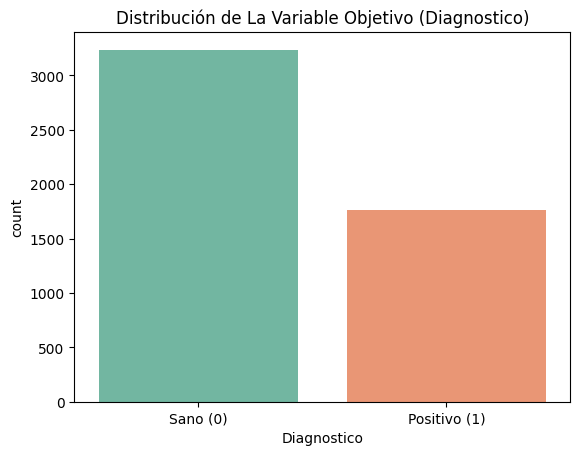

In [118]:
# Herramientas para Graficar 

plt.figure()
sns.countplot(x='Diagnostico', data=df, palette='Set2')
plt.title('Distribución de La Variable Objetivo (Diagnostico)')
plt.xticks([0, 1], ['Sano (0)', 'Positivo (1)'])

plt.show()



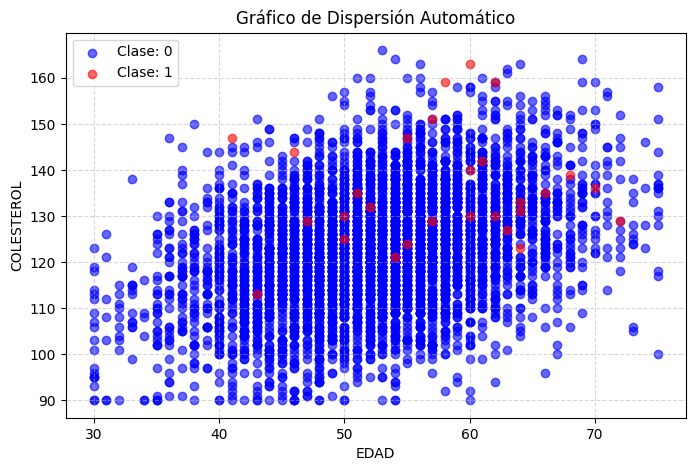

In [119]:


if isinstance(X, pd.DataFrame):
    x_val = X.iloc[:, 0].to_numpy()
    y_val = X.iloc[:, 1].to_numpy()
else:
    x_val = np.array(X[:, 0])
    y_val = np.array(X[:, 1])


y_arr = np.array(y).flatten()

#  Identificar automáticamente qué etiquetas reales contiene  'y'
clases_reales = np.unique(y_arr)

#  Dibujar el gráfico sobre las clases que encuentre el sistema
plt.figure(figsize=(8, 5))
colores = ['blue', 'red', 'green', 'purple'] # Lista de colores por si acaso

for i, clase in enumerate(clases_reales):
   
    mascara = (y_arr == clase)
    
    
    plt.scatter(
        x_val[mascara], 
        y_val[mascara], 
        color=colores[i % len(colores)], 
        label=f'Clase: {clase}', 
        alpha=0.6
    )

# 4. Configuración visual básica
plt.title('Gráfico de Dispersión Automático')
plt.xlabel('EDAD')
plt.ylabel('COLESTEROL')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()


In [120]:
4. # PREPROCESAMIENTO DE DATOS 

X  = df.drop('Diagnostico', axis=1) # Conserva todas las columnas excepto 'Diagnostico'

y = df['Diagnostico']

In [121]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y) # Dividimos el entrenamiento y prueba un 80% / 20%


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

modelos = {
    'Regresión Logística': LogisticRegression(class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    'SVM (Soporte Vectorial)':  SVC(probability=True, class_weight='balanced', random_state=42)
}

resultados_pred = {}
resultados_prob = {}

for nombre, modelo in modelos.items():
    # Entrenar e interceptar predicciones
    modelo.fit(X_train_scaled, y_train)

    resultados_pred[nombre] = modelo.predict(X_test_scaled)
    resultados_prob[nombre] = modelo.predict_proba(X_test_scaled)[:, 1]



c:\Users\lolit\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(



 MODELO: Regresión Logística
Exactitud (Accuracy): 0.6810
              precision    recall  f1-score   support

        Sano       0.80      0.68      0.73       647
    Positivo       0.54      0.68      0.60       353

    accuracy                           0.68      1000
   macro avg       0.67      0.68      0.67      1000
weighted avg       0.71      0.68      0.69      1000

------------------------------------------------------------

 MODELO: Random Forest
Exactitud (Accuracy): 0.6600
              precision    recall  f1-score   support

        Sano       0.75      0.70      0.73       647
    Positivo       0.52      0.58      0.55       353

    accuracy                           0.66      1000
   macro avg       0.64      0.64      0.64      1000
weighted avg       0.67      0.66      0.66      1000

------------------------------------------------------------

 MODELO: SVM (Soporte Vectorial)
Exactitud (Accuracy): 0.6900
              precision    recall  f1-score   sup

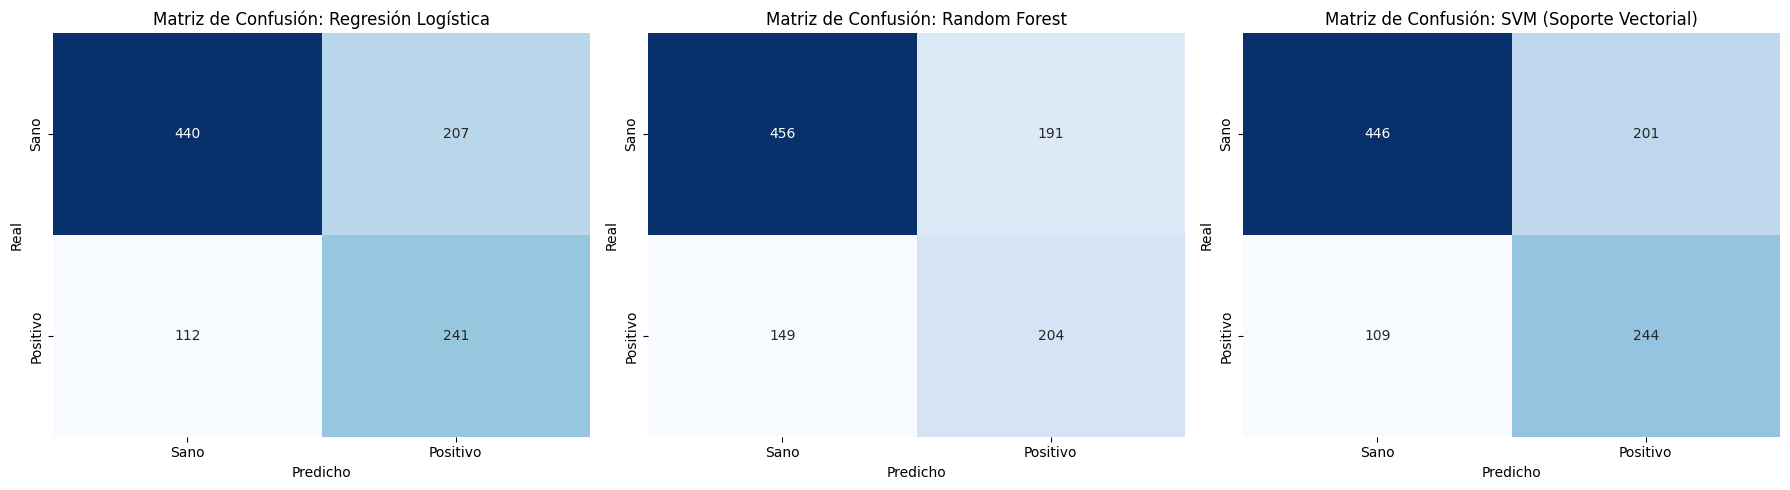

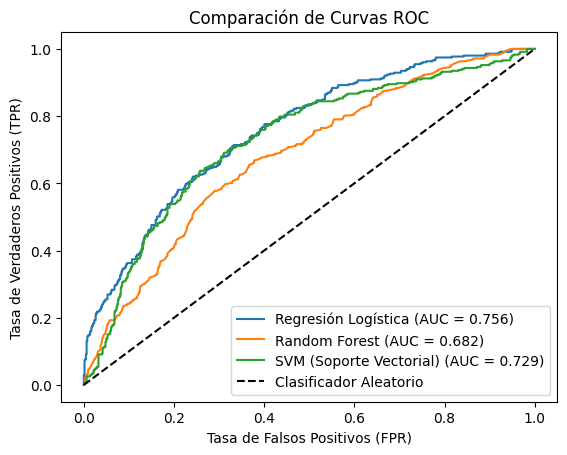

In [122]:
5. # ENTRENAMIENTO Y PREDICCIÓN DE MODELOS

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (nombre, y_pred) in enumerate(resultados_pred.items()):
    acc = accuracy_score(y_test, y_pred)
    print(f"\n MODELO: {nombre}")
    print(f"Exactitud (Accuracy): {acc:.4f}")
    print(classification_report(y_test, y_pred, target_names=['Sano', 'Positivo']))
    print("-"*60)
    
    # Gráfico 3: Matrices de Confusión individuales
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False)
    axes[i].set_title(f'Matriz de Confusión: {nombre}')
    axes[i].set_xlabel('Predicho')
    axes[i].set_ylabel('Real')
    axes[i].set_xticklabels(['Sano', 'Positivo'])
    axes[i].set_yticklabels(['Sano', 'Positivo'])

plt.tight_layout()
plt.show()

# Gráfico 4: Curva ROC para comparar rendimiento predictivo de fondo
plt.figure()
for nombre, y_prob in resultados_prob.items():
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{nombre} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Clasificador Aleatorio')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Comparación de Curvas ROC')
plt.legend(loc='lower right')
plt.show()

